**This uses the data simulated in the `simulations` directory of this project.**

# Prelim

In [1]:
library(dplyr)
library(stringr)
library(tidyr)
library(ggplot2)

fig_size = function(width, heigth){
    options(repr.plot.width = width, repr.plot.height = heigth)
}

color_key = list(
    'human gwas' = 'lightpink1',
    'human eqtls' = 'firebrick1',
    'human coloc' = 'firebrick4',
    'pig gwas' = 'lightskyblue1',
    'pig eqtls' = 'royalblue1',
    'pig coloc' = 'navyblue',
    'cattle gwas' = 'mediumpurple1',
    'cattle eqtls' = 'purple',
    'cattle coloc' = 'purple4',
    'human' = 'firebrick1',
    'pig' = 'royalblue1',
    'cattle' = 'purple'
)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Figure 2A

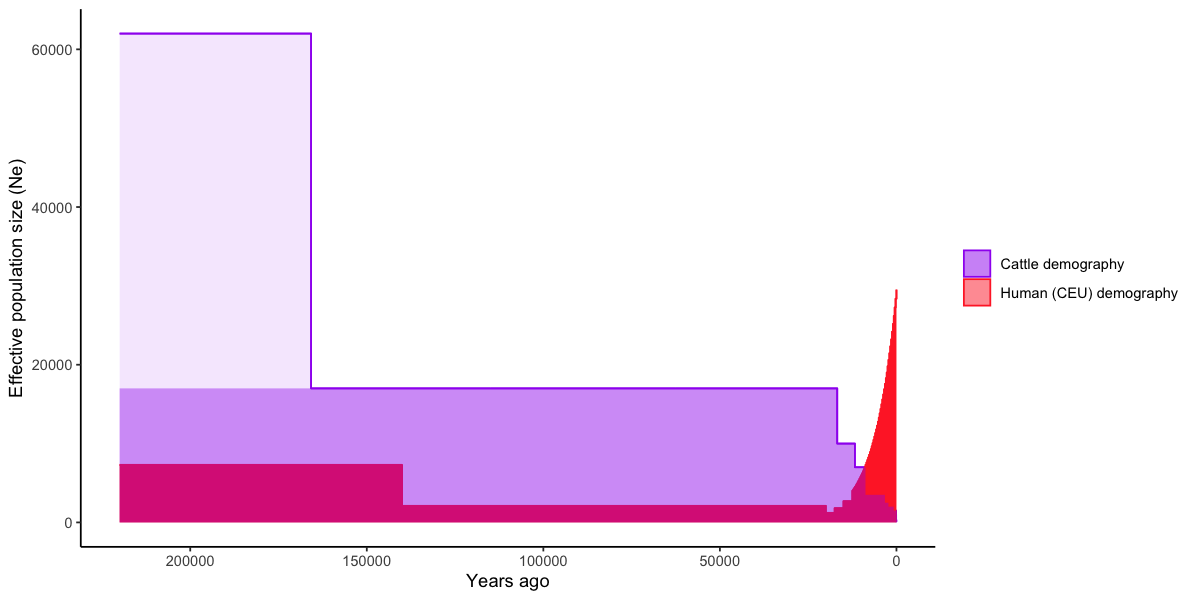

In [2]:
cattle_demo = data.frame(
    species = 'cattle',
    gen_ago = c(44000, 33154, 3354, 2354, 1754, 654, 454, 154, 24, 18, 12, 6, 3),
    Ne = c(6.2e4, 1.7e4, 1e4, 7e3, 3.5e3, 2.5e3, 2e3, 1.5e3, 1e3, 350, 250, 120, 90)
)
cattle_demo$years_ago = cattle_demo$gen_ago * 5

anc_pop = 7300
anc_gen_ago = 8800
ooa_pop = 2100
ooa_gen_ago = 5600
eu_as_gen_ago = 848
eu_as_pop = 1000
growth_rate = 0.004

human_ne = function(gen_ago) {
    if(gen_ago > ooa_gen_ago) {
        return(anc_pop)
    } else if (gen_ago <= ooa_gen_ago && gen_ago > eu_as_gen_ago) {
        return(ooa_pop)
    } else if (gen_ago <= eu_as_gen_ago) {
        return(eu_as_pop * (1+growth_rate)^(eu_as_gen_ago - gen_ago))
    }
}

human_demo = data.frame(
    species = 'human',
    gen_ago = c(seq(anc_gen_ago, 500, -100), seq(490, 0, -10))
)
human_demo$Ne = sapply(human_demo$gen_ago, human_ne)
human_demo$years_ago = human_demo$gen_ago * 25

demos = rbind(cattle_demo, human_demo)

# This is just a fast way to get the fill correct
shifted_cattle = cattle_demo[2:nrow(cattle_demo), c(1,4)]
shifted_cattle$years_ago = shifted_cattle$years_ago + 1
shifted_cattle$Ne = cattle_demo$Ne[1:(nrow(cattle_demo)-1)]

shifted_human = human_demo[2:nrow(human_demo), c(1,4)]
shifted_human$years_ago = shifted_human$years_ago + 1
shifted_human$Ne = human_demo$Ne[1:(nrow(human_demo)-1)]

boxes = rbind(
    demos %>% select(species, years_ago, Ne),
    shifted_cattle,
    shifted_human
)

fig_size(10,5)

# I have have this double plotted stuff to make part of the box paler
boxes = boxes %>% mutate(alp = ifelse(species=='cattle', 0.2, 0.5))
boxes2 = boxes %>% filter(species=='cattle') %>% mutate(Ne = ifelse(Ne == 62000, 17000, Ne), alp = 0.3)

boxes %>%
arrange(species, desc(years_ago)) %>%
ggplot(aes(x=years_ago, y=Ne, color=species, fill=species)) + 
    scale_x_reverse() + geom_step(show.legend=F) + theme_classic() +
    xlab('Years ago') + ylab('Effective population size (Ne)') + theme(legend.title=element_blank()) +
    geom_area(position='identity', aes(alpha=alp)) +
    geom_area(data=boxes2, aes(x=years_ago, y=Ne, alpha=alp), color=NA, fill=color_key[['cattle']], show.legend=F) + 
    scale_color_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
    scale_fill_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
    scale_alpha(guide='none') +
    guides(fill = guide_legend(override.aes = list(alpha = 0.5)))

Warning message:
“Removed 139 rows containing non-finite outside the scale range
(`stat_align()`).”
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_align()`).”
Warning message:
“Removed 139 rows containing missing values or values outside the scale range
(`geom_step()`).”


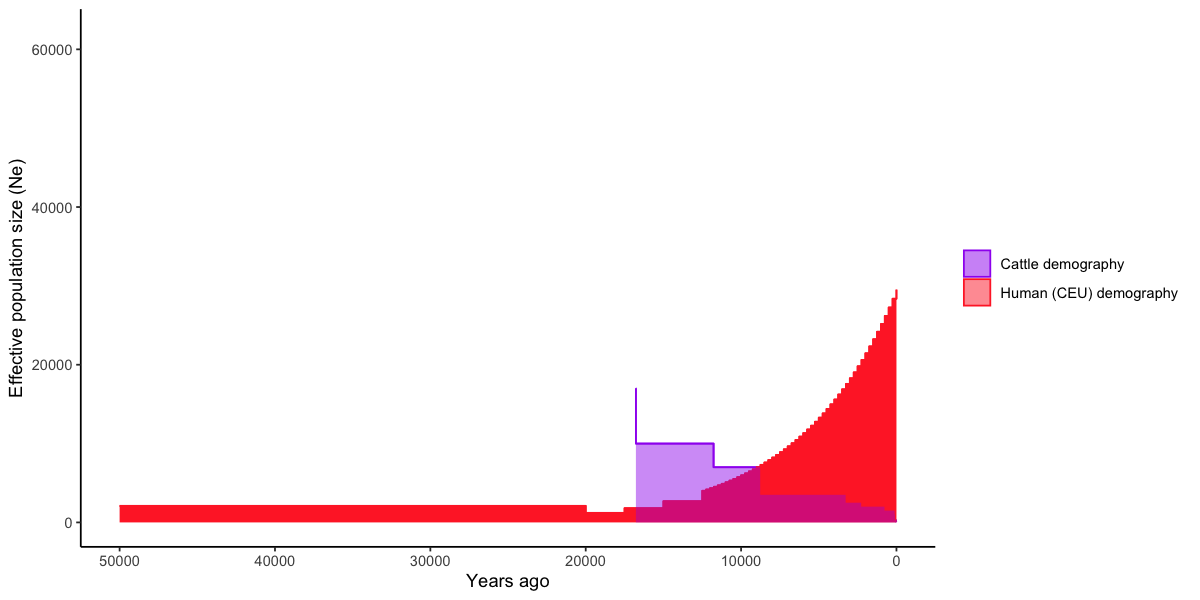

In [ ]:
# cattle_demo = data.frame(
#     species = 'cattle',
#     gen_ago = c(44000, 33154, 3354, 2354, 1754, 654, 454, 154, 24, 18, 12, 6, 3),
#     Ne = c(6.2e4, 1.7e4, 1e4, 7e3, 3.5e3, 2.5e3, 2e3, 1.5e3, 1e3, 350, 250, 120, 90)
# )
# cattle_demo$years_ago = cattle_demo$gen_ago * 5

# anc_pop = 7300
# anc_gen_ago = 8800
# ooa_pop = 2100
# ooa_gen_ago = 5600
# eu_as_gen_ago = 848
# eu_as_pop = 1000
# growth_rate = 0.004

# human_ne = function(gen_ago) {
#     if(gen_ago > ooa_gen_ago) {
#         return(anc_pop)
#     } else if (gen_ago <= ooa_gen_ago && gen_ago > eu_as_gen_ago) {
#         return(ooa_pop)
#     } else if (gen_ago <= eu_as_gen_ago) {
#         return(eu_as_pop * (1+growth_rate)^(eu_as_gen_ago - gen_ago))
#     }
# }

# human_demo = data.frame(
#     species = 'human',
#     gen_ago = c(seq(anc_gen_ago, 500, -100), seq(490, 0, -10))
# )
# human_demo$Ne = sapply(human_demo$gen_ago, human_ne)
# human_demo$years_ago = human_demo$gen_ago * 25

# demos = rbind(cattle_demo, human_demo)

# # This is just a fast way to get the fill correct
# shifted_cattle = cattle_demo[2:nrow(cattle_demo), c(1,4)]
# shifted_cattle$years_ago = shifted_cattle$years_ago + 1
# shifted_cattle$Ne = cattle_demo$Ne[1:(nrow(cattle_demo)-1)]

# shifted_human = human_demo[2:nrow(human_demo), c(1,4)]
# shifted_human$years_ago = shifted_human$years_ago + 1
# shifted_human$Ne = human_demo$Ne[1:(nrow(human_demo)-1)]

# boxes = rbind(
#     demos %>% select(species, years_ago, Ne),
#     shifted_cattle,
#     shifted_human
# )

# fig_size(10,5)

# # I have have this double plotted stuff to make part of the box paler
# boxes = boxes %>% mutate(alp = ifelse(species=='cattle', 0.2, 0.5))
# boxes2 = boxes %>% filter(species=='cattle') %>% mutate(Ne = ifelse(Ne == 62000, 17000, Ne), alp = 0.3)

# boxes %>%
# arrange(species, desc(years_ago)) %>%
# ggplot(aes(x=years_ago, y=Ne, color=species, fill=species)) + 
#     geom_step(show.legend=F) + theme_classic() +
#     xlab('Years ago') + ylab('Effective population size (Ne)') + theme(legend.title=element_blank()) +
#     geom_area(position='identity', aes(alpha=alp)) +
#     geom_area(data=boxes2, aes(x=years_ago, y=Ne, alpha=alp), color=NA, fill=color_key[['cattle']], show.legend=F) + 
#     scale_color_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
#     scale_fill_manual(values=c('cattle'=color_key[['cattle']], 'human'=color_key[['human']]), labels=c('Cattle demography', 'Human (CEU) demography')) +
#     scale_alpha(guide='none') +
#     guides(fill = guide_legend(override.aes = list(alpha = 0.5))) + 
#     scale_x_continuous(trans = scales::transform_compose('reverse'), limits=c(50000, 0))
#     # scale_x_continuous(trans = scales::transform_compose('log10','reverse'))

# Data for figures 2B and 2C

## Data reading

I just pulled out all top GWAS P-values with `gawk 'BEGIN {OFS="\t"} FNR == 1 {min_p=1} $15 < min_p {min_p=$15; out=$0} ENDFILE {print FILENAME"\t"out}' *linear > ../all_association_lead_snps.tsv`

(Note: ENDFILE only appears in recent-ish versions of awk)

In [40]:
ddir = '~/comparative_colocalization/data/simulations/'

extract_gtex = function(enloc_name) {
    str_extract(enloc_name, 'gtex_scaling_[0-9]+_[^:]*tr[0-9]+') %>% str_replace('.*_', '')
}

extract_gwas = function(enloc_name){
    gwas_names = str_extract_all(enloc_name, 'gwas_scaling_[0-9]+_[^:]*tr[0-9]+', simplify=T)
    gwas_names = unlist(gwas_names) %>% str_replace('.*_', '')
    # gwas_names = apply(gwas_names, 2, unlist)
    return(gwas_names)
}

extract_traits = function(df) {
    df$gtex = sapply(df$Signal, function(x) extract_gtex(x), USE.NAMES=F)
    df$gwas = sapply(df$Signal, function(x) extract_gwas(x), USE.NAMES=F)
    return(df)
}

In [ ]:
ps = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/all_association_lead_snps.tsv'),
    col.names=c('file', 'chr', 'pos', 'id', 'ref', 'alt', 'provisional_ref', 'a1', 'omitted', 'a1_freq', 'test', 'obs_ct', 'beta', 'se', 't_stat', 'p', 'errcode'),
    sep='\t') %>%
    select(-provisional_ref, -omitted, -test, -obs_ct, -t_stat, -errcode) %>%
    mutate(
        category = gsub('_.*', '', file),
        trait = stringr::str_extract(file, 'tr[0-9]+'),
        trait_pos = as.numeric(gsub('tr', '', trait))
    )

cgwas_vars = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/cgwas_vars_scaling_35.tsv'), header=T, as.is=T) %>%
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, time, daf, maf, selco, Vs, position) %>% 
    rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs)
cgtex_vars = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/cgtex_vars_scaling_35.tsv'), header=T, as.is=T) %>%
    mutate(gtex = paste0('tr', position)) %>% 
    select(gtex, time, daf, maf, selco, Vs, position) %>% 
    rename(gtex_time = time, gtex_daf = daf, gtex_maf = maf, gtex_selco = selco, gtex_Vs = Vs)
hgwas_vars = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/hgwas_vars_scaling_35.tsv'), header=T, as.is=T) %>%
    mutate(gwas = paste0('tr', position)) %>% 
    select(gwas, time, daf, maf, selco, Vs, position) %>% 
    rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs)
hgtex_vars = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/hgtex_vars_scaling_35.tsv'), header=T, as.is=T) %>%
    mutate(gtex = paste0('tr', position)) %>% 
    select(gtex, time, daf, maf, selco, Vs, position) %>% 
    rename(gtex_time = time, gtex_daf = daf, gtex_maf = maf, gtex_selco = selco, gtex_Vs = Vs)

cenloc = read.table(paste0(ddir, 'fastenloc/cattle_fastenloc.enloc.sig.out'), header=T, as.is=T)
cenloc = extract_traits(cenloc) %>% unnest(cols=c(gwas), keep_empty=T) %>% 
    unnest(cols=c(gwas), keep_empty=T)
henloc = read.table(paste0(ddir, 'fastenloc/human_fastenloc.enloc.sig.out'), header=T, as.is=T)
henloc = extract_traits(henloc) %>% unnest(cols=c(gwas), keep_empty=T) %>% 
    unnest(cols=c(gwas), keep_empty=T)

cenloc = cenloc %>% 
    left_join(., cgtex_vars, by='gtex') %>% 
    left_join(., cgwas_vars, by='gwas') %>% 
    mutate(correct = !is.na(gwas) & gtex == gwas) %>%
    left_join(
        ps %>% filter(category == 'cgwas') %>% rename(position.x = trait_pos, min_snp_pos_gwas = pos) %>% select(position.x, min_snp_pos_gwas)
    ) %>% left_join(
        ps %>% filter(category == 'cgwas') %>% rename(position.y = trait_pos, min_snp_pos_gtex = pos) %>% select(position.y, min_snp_pos_gtex)
    )
henloc = henloc %>% 
    left_join(., hgtex_vars, by='gtex') %>% 
    left_join(., hgwas_vars, by='gwas') %>% 
    mutate(correct = !is.na(gwas) & gtex == gwas) %>%
    left_join(
        ps %>% filter(category == 'hgwas') %>% rename(position.x = trait_pos, min_snp_pos_gwas = pos) %>% select(position.x, min_snp_pos_gwas)
    ) %>% left_join(
        ps %>% filter(category == 'hgtex') %>% rename(position.y = trait_pos, min_snp_pos_gtex = pos) %>% select(position.y, min_snp_pos_gtex)
    )

br = c(-0.5, -0.3, -0.2, -0.1, -0.05, -0.025, -0.01, -0.005, -0.001, 0, 1)
cenloc = cenloc %>% mutate(selco_bin = cut(gtex_selco, breaks=br))
henloc = henloc %>% mutate(selco_bin = cut(gtex_selco, breaks=br))

cgwas_traits = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/cgwas_scaling_35_pheno.sbams'), header=T)[, 2]
cgtex_traits = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/cgtex_scaling_35_pheno.sbams'), header=T)[, 2]
hgwas_traits = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/hgwas_scaling_35_pheno.sbams'), header=T)[, 2]
hgtex_traits = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/gwas_35_gtex_35/hgtex_scaling_35_pheno.sbams'), header=T)[, 2]

ctraits = intersect(cgwas_traits, cgtex_traits)
htraits = intersect(hgwas_traits, hgtex_traits)

Joining with `by = join_by(position.x)`
Joining with `by = join_by(position.y)`
Joining with `by = join_by(position.x)`
Joining with `by = join_by(position.y)`


## Data reorganizing

In [6]:
get_enloc_df_rcp = function(rcp_cutoff = 0.5, dist_cutoff = 1e5, hypothetical_gwas_size = 100000, p_thresh=1, pow_est=0, br = -1*c(Inf, 2**seq(-7, -15), 0), maf_br = seq(0, 0.5, 0.05), print_rates=T, power_filter=F, maf_thresh=0, seed=19930224) {
    p_cut = qchisq(p=p_thresh, df=1, lower.tail=F)

    enloc_df = rbind(
        cgwas_vars %>% left_join(., 
            cenloc %>% mutate(trait_dist = abs(min_snp_pos_gwas - min_snp_pos_gtex)) %>% select(Signal, gwas, CPIP_qtl, CPIP_gwas_marginal, CPIP_gwas_qtl_prior, RCP, correct, trait_dist, min_snp_pos_gwas, min_snp_pos_gtex) %>% arrange(desc(correct)), multiple='first', by = join_by(gwas)
        ) %>%
            filter(gwas_selco < 0) %>% 
            mutate(species='cattle'),
        hgwas_vars %>% left_join(., 
            henloc %>% mutate(trait_dist = abs(min_snp_pos_gwas - min_snp_pos_gtex)) %>% select(Signal, gwas, CPIP_qtl, CPIP_gwas_marginal, CPIP_gwas_qtl_prior, RCP, correct, trait_dist, min_snp_pos_gwas, min_snp_pos_gtex) %>% arrange(desc(correct)), multiple='first', by = join_by(gwas)
        ) %>%
            filter(gwas_selco < 0) %>% 
            mutate(species='human')
    ) %>%
        filter(position > 5e5 & position < 1e7-5e5 & gwas_maf >= maf_thresh) %>% 
        mutate(
            beta = sqrt(abs(gwas_selco)*35),
            vs = beta^2 * gwas_maf * (1 - gwas_maf),
            n_hypo = hypothetical_gwas_size,
            NCP = hypothetical_gwas_size * vs / (1-vs),
            power_estimated = pchisq(q=p_cut, df=1, ncp=NCP, lower.tail=F)
        ) %>%
        filter(power_estimated > pow_est) %>%
        mutate(
            trait_dist = ifelse(is.na(trait_dist), 0, trait_dist),
            outcome = ifelse(is.na(correct) | (!is.na(RCP) & RCP < rcp_cutoff) | trait_dist > dist_cutoff, 'underpowered', ifelse(correct, 'correct', 'incorrect')),
            RCP = ifelse(RCP > 1, 1, RCP),
            RCP = ifelse(is.na(RCP), 0, RCP),
            selco_bin = cut(gwas_selco, breaks = br),
            maf_bin = cut(gwas_maf, breaks = maf_br)
        )

    if (print_rates) {
        table(enloc_df$species, enloc_df$outcome)
        cat('Cattle success rate:', sum(enloc_df$species == 'cattle' & enloc_df$outcome == 'correct')/sum(enloc_df$species == 'cattle'), '\n')
        cat('Human success rate:', sum(enloc_df$species == 'human' & enloc_df$outcome == 'correct')/sum(enloc_df$species == 'human'), '\n')

        # enloc_df %>%
        #     # filter(power_estimated > power_cutoff) %>%
        #     group_by(species) %>%
        #     summarize(
        #         correct = sum(outcome == 'correct'),
        #         underpowered = sum(outcome == 'underpowered'),
        #         incorrect = sum(outcome == 'incorrect'),
        #         success_rate = sum(outcome == 'correct') / n()) %>% print()
    }

    if (power_filter) {
        enloc_df = power_filterer(enloc_df, seed=seed, print_rates=print_rates)
    }
    
    return(enloc_df)
}

power_filterer = function(df, seed=19930224, print_rates=T) {
    set.seed(seed)
    enloc_df = df %>%
        mutate(rand = runif(n())) %>%
        filter(rand < power_estimated)

    if (print_rates) {
        print(paste('Number of traits drops from', nrow(df), 'to', nrow(enloc_df)))
        cat('Cattle success rate:', sum(enloc_df$species == 'cattle' & enloc_df$outcome == 'correct')/sum(enloc_df$species == 'cattle'), '\n')
        cat('Human success rate:', sum(enloc_df$species == 'human' & enloc_df$outcome == 'correct')/sum(enloc_df$species == 'human'), '\n')

        # enloc_df %>%
        #     filter(power_estimated > power_cutoff) %>%
        #     group_by(species) %>%
        #     summarize(
        #         correct = sum(outcome == 'correct'),
        #         underpowered = sum(outcome == 'underpowered'),
        #         incorrect = sum(outcome == 'incorrect'),
        #         success_rate = sum(outcome == 'correct') / n()) %>% print()
    }

    return(enloc_df)
}

hvars = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/human_simulated_variants.tsv'), header=T, as.is=T)
cvars = read.table(paste0(ddir, 'gwas_and_eqtl_mapping/cattle_simulated_variants.tsv'), header=T, as.is=T)

variants = rbind(
    hvars %>% mutate(species='human'),
    cvars %>% mutate(species='cattle')
) %>% 
    mutate(species = factor(species, levels=c('human', 'cattle')))

# Figure 2B

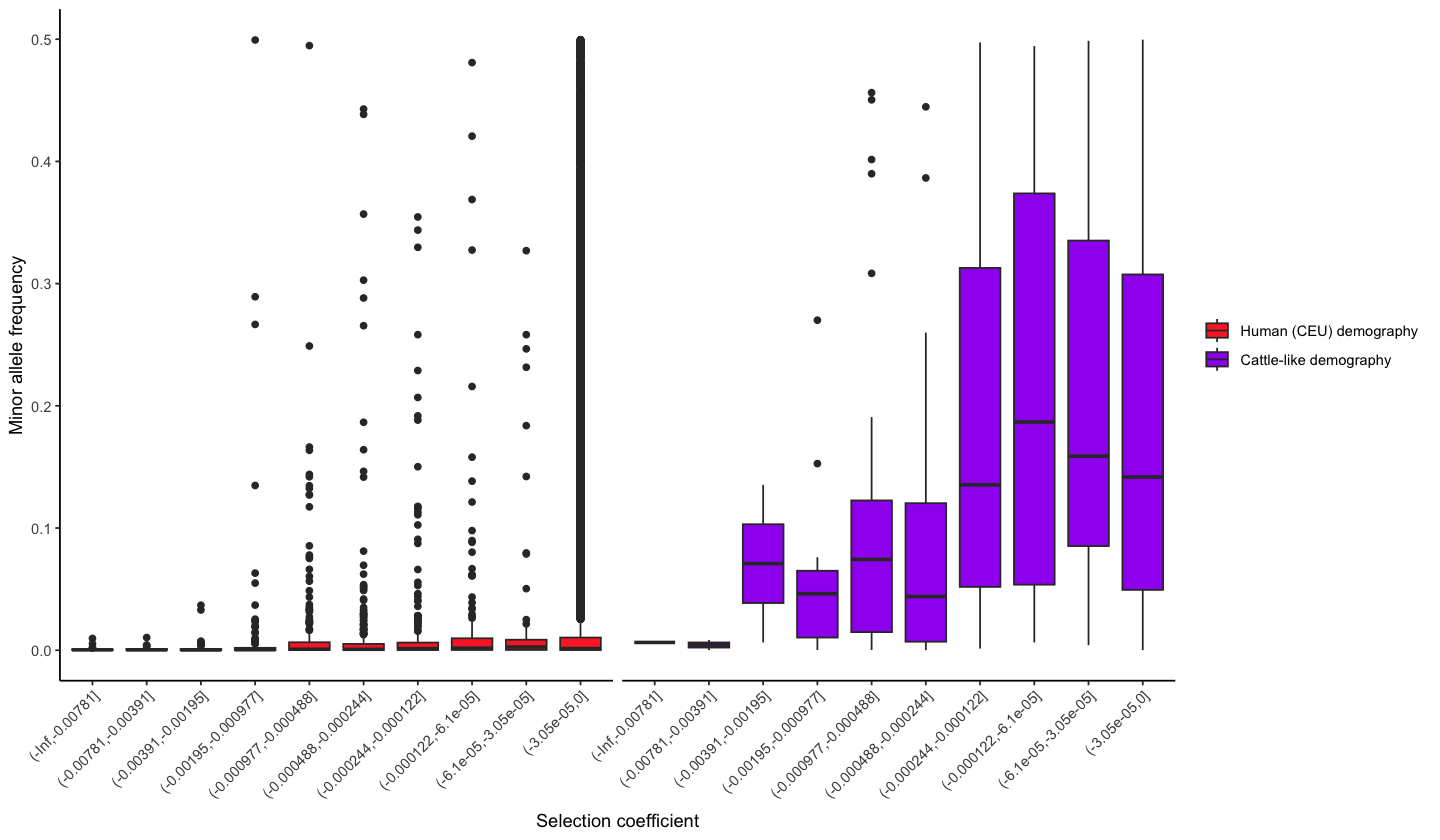

In [5]:
# Create some bins for selection coefficient
br = -1*c(Inf, 2**seq(-7, -15), 0)

fig_size(12,7)

variants %>% 
    dplyr::mutate(selco_bin = cut(selco, breaks = br)) %>% 
    group_by(selco_bin, species) %>%
    filter(!is.na(selco_bin)) %>%
ggplot(aes(x = selco_bin, y = maf, fill = species)) + geom_boxplot() + theme_classic() + facet_wrap(~species) +
    theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1), legend.title=element_blank(), strip.text.x=element_blank()) + 
    xlab('Selection coefficient') + ylab('Minor allele frequency') +
    scale_fill_manual(values = c('human'=color_key[['human']], 'cattle'=color_key[['cattle']]), labels = c('Human (CEU) demography', 'Cattle-like demography'))

# Figure 2C

In [55]:
make_enloc_long = function(df) {
    df = df %>% 
        mutate(gtex = gsub('\\(.*', '', Signal), gwas = gsub('.*)', '', Signal)) %>% 
        separate_longer_delim(gwas, 'gwas_scaling_35_') %>% 
        mutate(
            gwas = gsub(':.*$', '', gsub('[hc]', '', gwas)),
            gtex = gsub(':.*$', '', gsub('cgtex_scaling_35_', '', gtex))
        ) %>%
        filter(gwas != '') %>% 
        rowwise() %>% mutate(RCP = min(c(RCP, 1)))
    return(df)
}

filter_by_gwas_power = function(df, hypothetical_gwas_size, selco_mult, p_cut, seed, apply_filt=F) {
    set.seed(seed)
    sig_thresh = qchisq(p_cut, df=1, lower.tail=F)
    df = df %>% mutate(
            beta = sqrt(abs(selco)*selco_mult),
            vs = 2 * beta^2 * maf * (1 - maf),
            # n_hypo = hypothetical_gwas_size,
            NCP = hypothetical_gwas_size * vs / (1-vs),
            power_estimated = pchisq(q=sig_thresh, df=1, ncp=NCP, lower.tail=F)
        )
    if (apply_filt) {
        df = df  %>%
        rowwise() %>% mutate(keep = power_estimated >= runif(1)) %>%
        filter(keep) %>% select(-keep)
    }
    return(df)
}

In [214]:
lc = make_enloc_long(cenloc)
lh = make_enloc_long(henloc)

br = c(-0.5, -0.3, -0.2, -0.1, -0.05, -0.025, -0.01, -0.005, -0.001, 0, 1)
maf_br = seq(0, 0.5, 0.05)

htraits = hvars %>% 
    filter(selco < 0) %>% 
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, selco, maf)

x = lh %>%
    group_by(gwas) %>%
    summarize(
        any_correct = any(gwas == gtex, RCP > 0.5),
        any_sig = any(RCP > 0.5),
        n_sig = sum(RCP > 0.5)
    )

htraits = htraits %>% 
    left_join(x) %>%
    replace_na(list(any_correct=F, any_sig=F, n_sig=0)) %>%
    mutate(
        species = 'human',
        outcome = ifelse(any_correct, 'correct', ifelse(any_sig, 'incorrect', 'underpowered')),
        selco_bin = cut(selco, breaks=br),
        maf_bin = cut(maf, breaks = maf_br)
    )

ctraits = cvars %>% 
    filter(selco < 0) %>% 
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, selco, maf)

x = lc %>%
    group_by(gwas) %>%
    summarize(
        any_correct = any(gwas == gtex, RCP > 0.5),
        any_sig = any(RCP > 0.5),
        n_sig = sum(RCP > 0.5)
    )

ctraits = ctraits %>% 
    left_join(x) %>%
    replace_na(list(any_correct=F, any_sig=F, n_sig=0)) %>%
    mutate(
        species = 'cattle',
        outcome = ifelse(any_correct, 'correct', ifelse(any_sig, 'incorrect', 'underpowered')),
        selco_bin = cut(selco, breaks=br),
        maf_bin = cut(maf, breaks = maf_br)
    )
traits = rbind(ctraits, htraits)

Joining with `by = join_by(gwas)`
Joining with `by = join_by(gwas)`


species,power
<chr>,<dbl>
cattle,0.55555556
human,0.03551046


species,power
<chr>,<dbl>
cattle,0.6979592
human,0.2000000


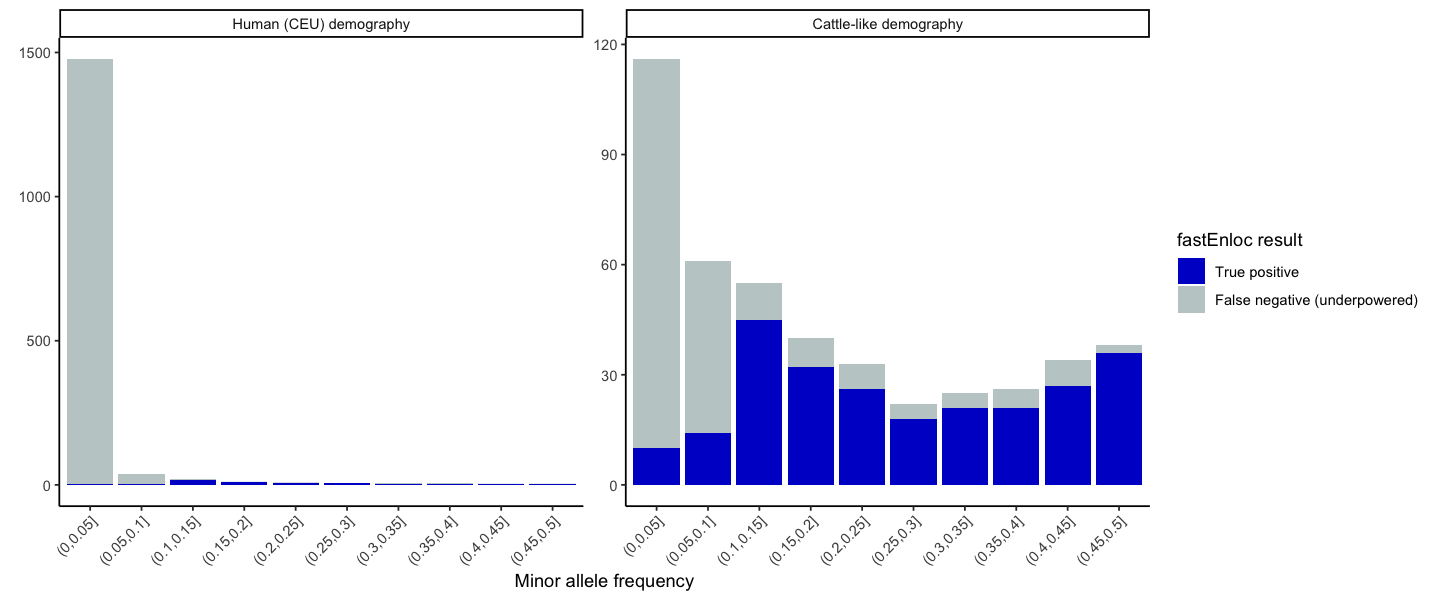

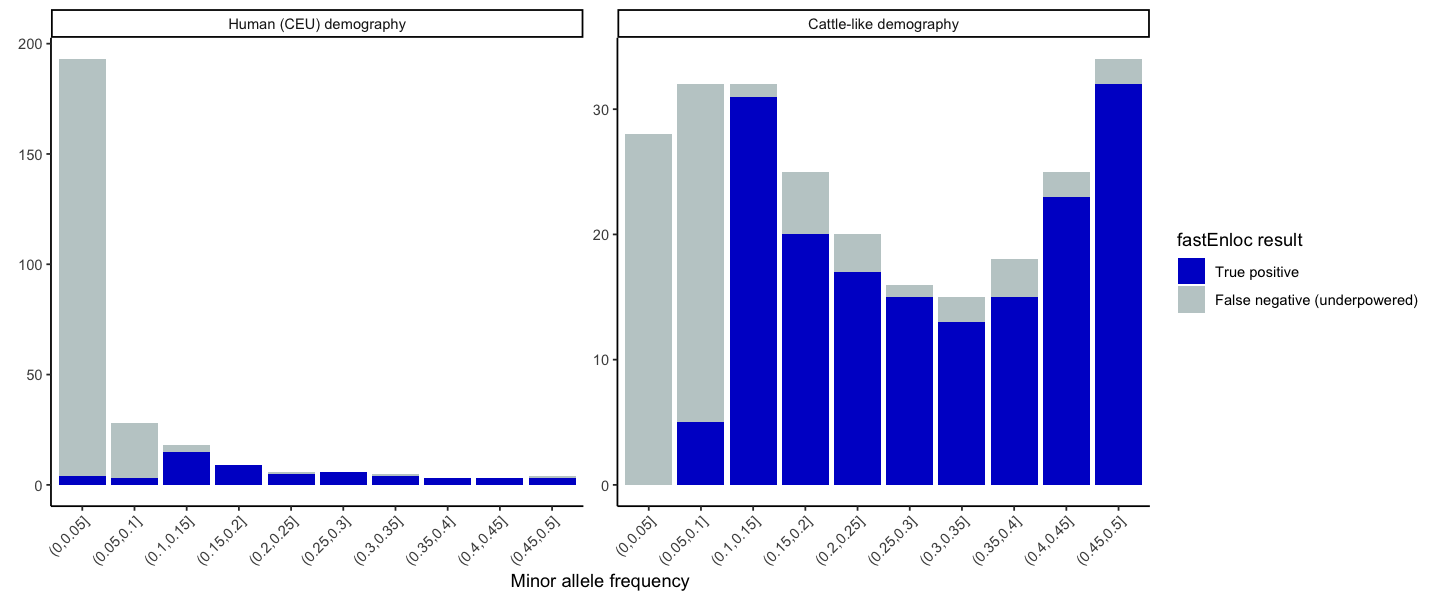

In [216]:
fig_size(12,5)

traits %>% group_by(species) %>% summarize(power = sum(outcome == 'correct')/n())

traits %>% 
    mutate(
        species = factor(species, levels=c('human', 'cattle')),
        outcome = factor(outcome, levels = c('underpowered', 'incorrect', 'correct'))) %>%
ggplot(aes(x = maf_bin, fill=outcome)) + geom_bar() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
    facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y') + 
    xlab('Minor allele frequency') + labs(fill = 'fastEnloc result') + ylab(element_blank()) + 
    scale_fill_manual(
        breaks=c('correct', 'incorrect', 'underpowered'), 
        values=c('blue3', 'lightpink3', 'azure3'),
        labels=c('True positive', 'False positive', 'False negative (underpowered)')
    )

filt = filter_by_gwas_power(traits, 1e5, 35, 5e-8, 19930224, apply_filt=T)
filt %>% group_by(species) %>% summarize(power = sum(outcome == 'correct')/n())

filt %>% 
    mutate(
        species = factor(species, levels=c('human', 'cattle')),
        outcome = factor(outcome, levels = c('underpowered', 'incorrect', 'correct'))) %>%
ggplot(aes(x = maf_bin, fill=outcome)) + geom_bar() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
    facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y') + 
    xlab('Minor allele frequency') + labs(fill = 'fastEnloc result') + ylab(element_blank()) + 
    scale_fill_manual(
        breaks=c('correct', 'incorrect', 'underpowered'), 
        values=c('blue3', 'lightpink3', 'azure3'),
        labels=c('True positive', 'False positive', 'False negative (underpowered)')
    )

# Supplementary figure: Allelic ages of simulated variants

All variants

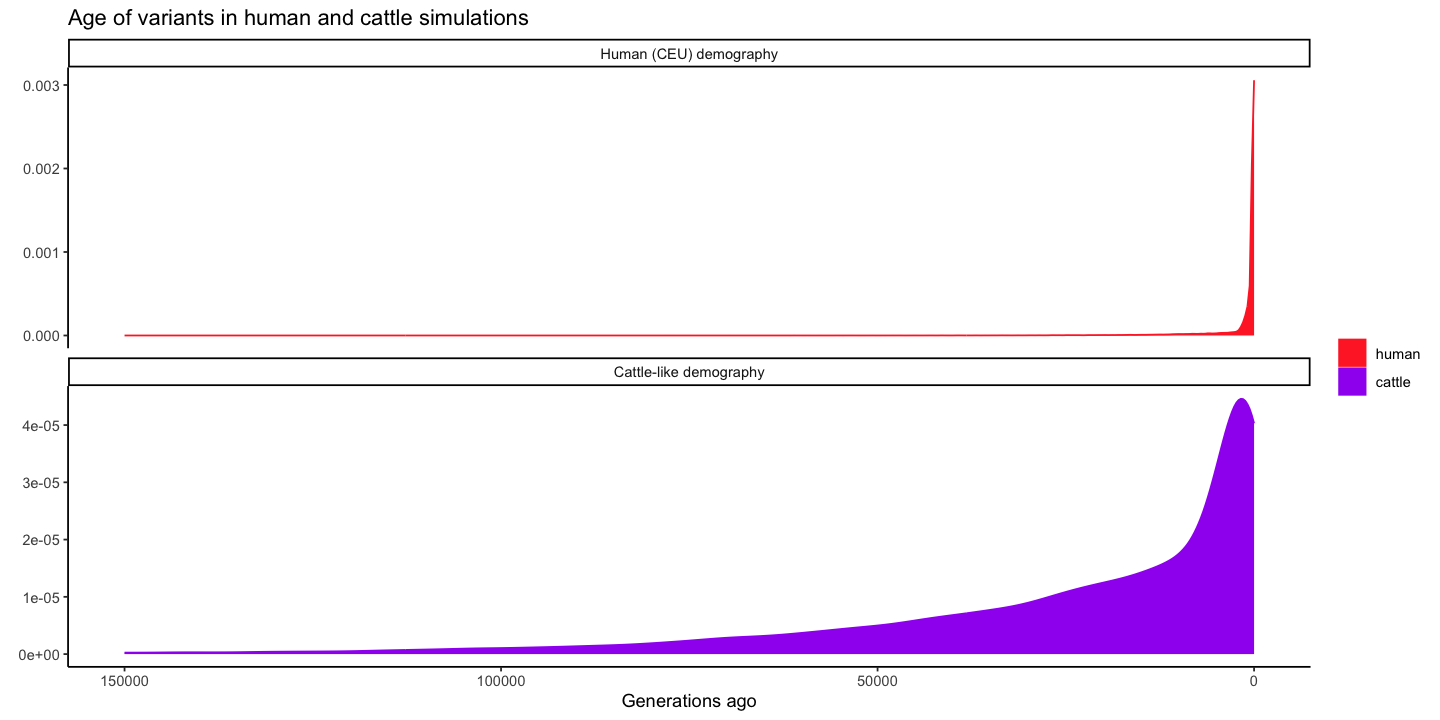

In [223]:
fig_size(12, 6)

variants %>%
    filter(maf > 0) %>%
ggplot(aes(x = time, color=species, fill=species)) + geom_density() + theme_classic() + 
    scale_x_reverse(limits=c(1.5e5, 0), oob=scales::oob_keep) + # facet_wrap(~species, ncol=1, scales='free_y') +
    facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y', ncol=1) + 
    scale_fill_manual(values=c('human'=color_key[['human']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'cattle'=color_key[['cattle']])) +
    theme(legend.title=element_blank()) + xlab('Generations ago') + ylab(element_blank()) +
    ggtitle('Age of variants in human and cattle simulations')

Variants with MAF > 0.01

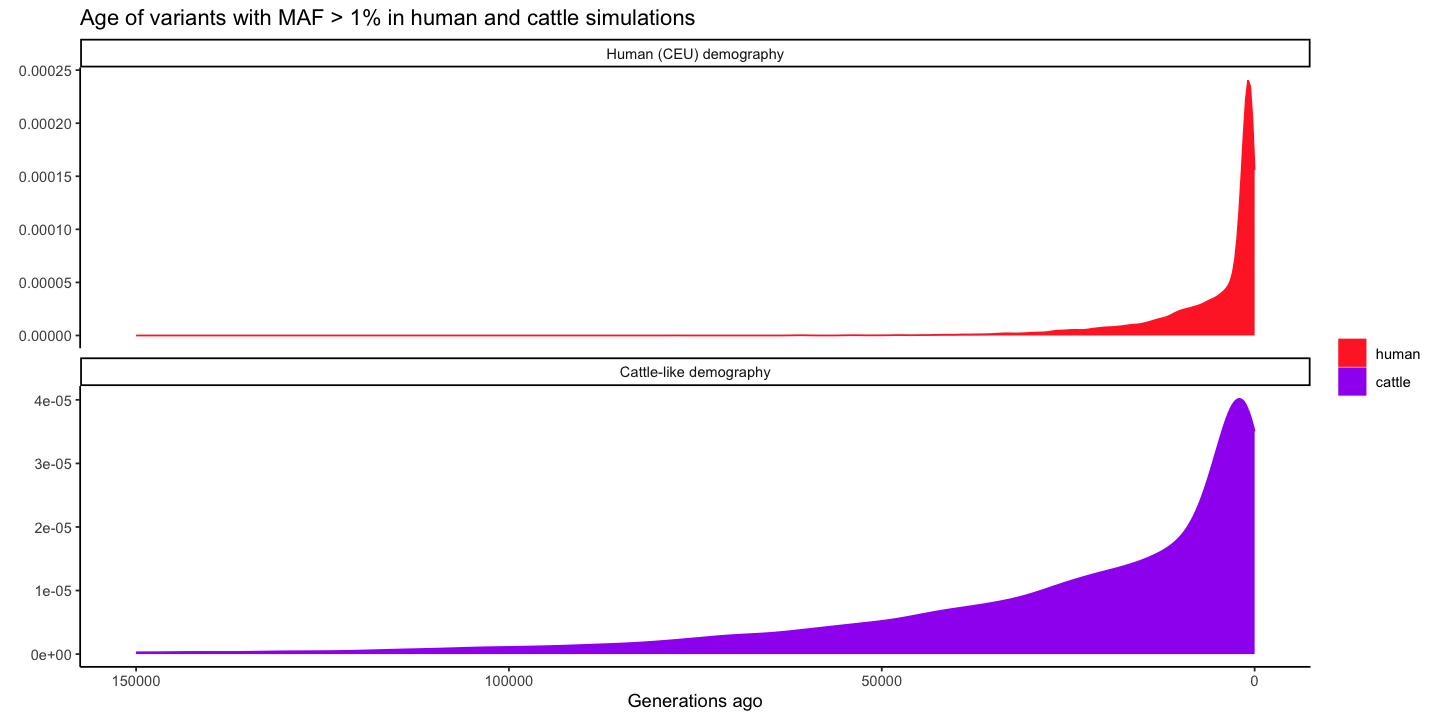

In [224]:
variants %>%
    filter(maf > 0.01) %>%
ggplot(aes(x = time, color=species, fill=species)) + geom_density() + theme_classic() + 
    scale_x_reverse(limits=c(1.5e5, 0), oob=scales::oob_keep) + # facet_wrap(~species, ncol=1, scales='free_y') +
    facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y', ncol=1) + 
    scale_fill_manual(values=c('human'=color_key[['human']], 'cattle'=color_key[['cattle']])) +
    scale_color_manual(values=c('human'=color_key[['human']], 'cattle'=color_key[['cattle']])) +
    theme(legend.title=element_blank()) + xlab('Generations ago') + ylab(element_blank()) +
    ggtitle('Age of variants with MAF > 1% in human and cattle simulations')

# Supplementary figure: Allele frequencies for revision simulations

In [26]:
cgwas_vars = read.table('~/comparative_colocalization/data/simulations/gwas_and_eqtl_mapping/gwas_35_gtex_35/cgwas_vars_scaling_35.tsv', header=T, as.is=T) %>%
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, time, daf, maf, selco, Vs, position) # %>% 
    # rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs)

# N.b. the "min_maf" in the filename refer to variants used for simulating traits, not to all variants recorded here.
cgwas_vars_selection = read.table('/Users/noah/tmp/selsims/selection_bottlenecked/outdir/gwas_35_gtex_35_maf_0.01/cgwas_vars_gwas_35_gtex_35_maf_0.01.tsv', header=T, as.is=T) %>%
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, time, daf, maf, selco, Vs, position) # %>% 
    # rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs)

cgwas_vars_selection_no_bottleneck = read.table('/Users/noah/tmp/selsims/selection_not_bottlenecked/outputs/gwas_35_gtex_35_maf_0.01/cgwas_vars_gwas_35_gtex_35_maf_0.01.tsv', header=T, as.is=T) %>%
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, time, daf, maf, selco, Vs, position) # %>% 
    # rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs)

In [37]:
br

[1]          -Inf -7.812500e-03 -3.906250e-03 -1.953125e-03 -9.765625e-04
 [6] -4.882812e-04 -2.441406e-04 -1.220703e-04 -6.103516e-05 -3.051758e-05
[11]  0.000000e+00 -5.000000e+00

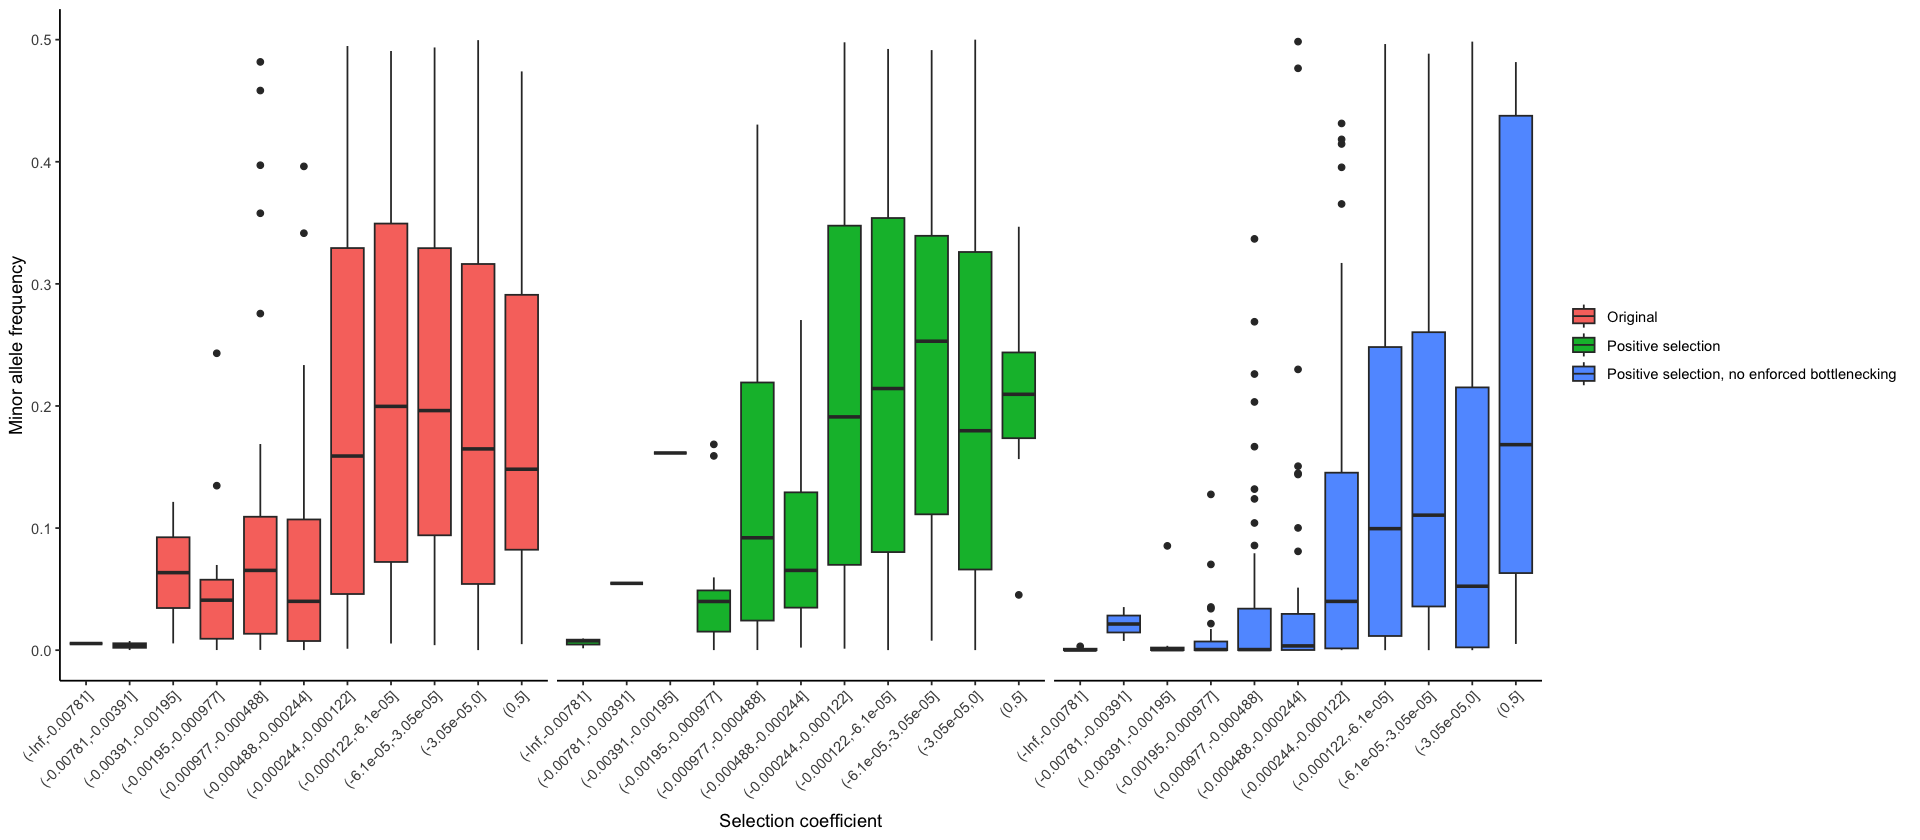

In [38]:
fig_size(16,7)

br = -1*c(Inf, 2**seq(-7, -15), 0, -5)

rbind(
    cgwas_vars %>% mutate(simulation = 'Original'),
    cgwas_vars_selection %>% mutate(simulation = 'Positive selection'),
    cgwas_vars_selection_no_bottleneck %>% mutate(simulation = 'Positive selection, no enforced bottlenecking')
) %>%
mutate(selco_bin = cut(selco, breaks = br)) %>%
# filter(!is.na(selco_bin), selco < 0) %>%
filter(!is.na(selco_bin)) %>%
ggplot(aes(x = selco_bin, y = maf, fill = simulation)) + geom_boxplot() + theme_classic() + facet_wrap(~simulation) +
    theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1), legend.title=element_blank(), strip.text.x=element_blank()) + 
    xlab('Selection coefficient') + ylab('Minor allele frequency') # +
    # scale_fill_manual(values = c('human'=color_key[['human']], 'cattle'=color_key[['cattle']]), labels = c('Human (CEU) demography', 'Cattle-like demography'))

# Supplementary figure: colocalization for cattle demography with positive selection and bottlenecking

In [ ]:
ddir = '/Users/noah/tmp/selsims/selection_bottlenecked/outdir/gwas_35_gtex_35_maf_0.01/'
enloc_dir = '/Users/noah/tmp/selsims/selection_bottlenecked/fastenloc/'

ps = read.table(paste0(ddir, 'plink_analysis/all_association_lead_snps.tsv'),
    col.names=c('file', 'chr', 'pos', 'id', 'ref', 'alt', 'provisional_ref', 'a1', 'omitted', 'a1_freq', 'test', 'obs_ct', 'beta', 'se', 't_stat', 'p', 'errcode'),
    sep='\t') %>%
    select(-provisional_ref, -omitted, -test, -obs_ct, -t_stat, -errcode) %>%
    mutate(
        category = gsub('_.*', '', file),
        trait = stringr::str_extract(file, 'tr[0-9]+'),
        trait_pos = as.numeric(gsub('tr', '', trait))
    )

cgwas_vars = read.table(paste0(ddir, 'cgwas_vars_gwas_35_gtex_35_maf_0.01.tsv'), header=T, as.is=T) %>%
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, time, daf, maf, selco, Vs, position) %>% 
    rename(gwas_time = time, gwas_daf = daf, gwas_maf = maf, gwas_selco = selco, gwas_Vs = Vs)
cgtex_vars = read.table(paste0(ddir, 'cgtex_vars_gwas_35_gtex_35_maf_0.01.tsv'), header=T, as.is=T) %>%
    mutate(gtex = paste0('tr', position)) %>% 
    select(gtex, time, daf, maf, selco, Vs, position) %>% 
    rename(gtex_time = time, gtex_daf = daf, gtex_maf = maf, gtex_selco = selco, gtex_Vs = Vs)

cenloc = read.table(paste0(enloc_dir, 'cattle_selection_bottleneck.enloc.sig.out'), header=T, as.is=T)
cenloc = extract_traits(cenloc) %>% unnest(cols=c(gwas), keep_empty=T) %>% 
    unnest(cols=c(gwas), keep_empty=T)

cenloc = cenloc %>% 
    left_join(., cgtex_vars, by='gtex') %>% 
    left_join(., cgwas_vars, by='gwas') %>% 
    mutate(correct = !is.na(gwas) & gtex == gwas) %>%
    left_join(
        ps %>% filter(category == 'cgwas') %>% rename(position.x = trait_pos, min_snp_pos_gwas = pos) %>% select(position.x, min_snp_pos_gwas)
    ) %>% left_join(
        ps %>% filter(category == 'cgwas') %>% rename(position.y = trait_pos, min_snp_pos_gtex = pos) %>% select(position.y, min_snp_pos_gtex)
    )

br = c(-0.5, -0.3, -0.2, -0.1, -0.05, -0.025, -0.01, -0.005, -0.001, 0, 1)
cenloc = cenloc %>% mutate(selco_bin = cut(gtex_selco, breaks=br))

cgwas_traits = read.table(paste0(ddir, 'cgwas_scaling_35_pheno.sbams'), header=T)[, 2]
cgtex_traits = read.table(paste0(ddir, 'cgtex_scaling_35_pheno.sbams'), header=T)[, 2]

ctraits = intersect(cgwas_traits, cgtex_traits)

Joining with `by = join_by(position.x)`
Joining with `by = join_by(position.y)`


In [ ]:
cvars = full_join(
    cgwas_vars %>% dplyr::rename(time=gwas_time, selco=gwas_selco),
    cgtex_vars %>% dplyr::rename(time=gtex_time, selco=gtex_selco),
    by=c('position', 'time', 'selco')
) %>% 
mutate(maf=(8*gwas_maf+gtex_maf)/9)

lc = make_enloc_long(cenloc)

br = c(-0.5, -0.3, -0.2, -0.1, -0.05, -0.025, -0.01, -0.005, -0.001, 0, 1)
maf_br = seq(0, 0.5, 0.05)

ctraits = cvars %>% 
    filter(selco < 0) %>% 
    mutate(gwas = paste0('tr', position)) %>%
    select(gwas, selco, maf)

x = lc %>%
    group_by(gwas) %>%
    summarize(
        any_correct = any(gwas == gtex, RCP > 0.5),
        any_sig = any(RCP > 0.5),
        n_sig = sum(RCP > 0.5)
    )

ctraits = ctraits %>% 
    left_join(x) %>%
    replace_na(list(any_correct=F, any_sig=F, n_sig=0)) %>%
    mutate(
        species = 'cattle',
        outcome = ifelse(any_correct, 'correct', ifelse(any_sig, 'incorrect', 'underpowered')),
        selco_bin = cut(selco, breaks=br),
        maf_bin = cut(maf, breaks = maf_br)
    )
# traits = rbind(ctraits, htraits)

Joining with `by = join_by(gwas)`


power
<dbl>
0.5837321


species,power
<chr>,<dbl>
cattle,0.6979592


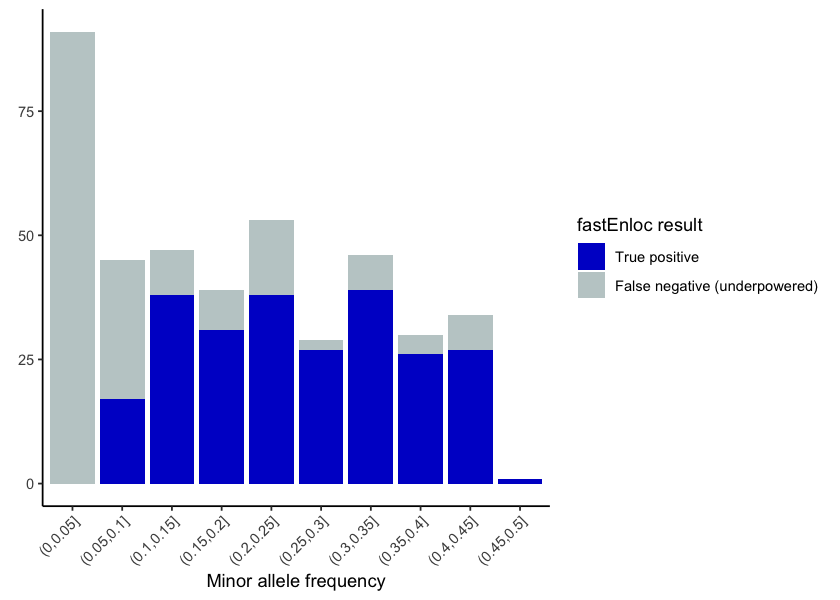

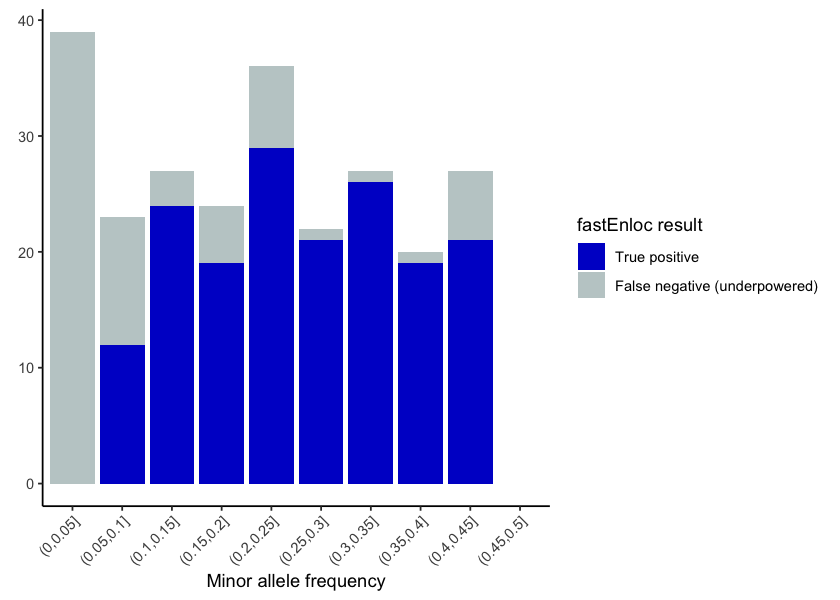

In [103]:
fig_size(7,5)

# traits %>% group_by(species) %>% summarize(power = sum(outcome == 'correct')/n())

ctraits %>% 
    mutate(
        # species = factor(species, levels=c('human', 'cattle')),
        outcome = factor(outcome, levels = c('underpowered', 'incorrect', 'correct'))) %>%
    filter(!is.na(maf_bin)) %>%
ggplot(aes(x = maf_bin, fill=outcome)) + geom_bar() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
    # facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y') + 
    xlab('Minor allele frequency') + labs(fill = 'fastEnloc result') + ylab(element_blank()) + 
    scale_fill_manual(
        breaks=c('correct', 'incorrect', 'underpowered'), 
        values=c('blue3', 'lightpink3', 'azure3'),
        labels=c('True positive', 'False positive', 'False negative (underpowered)')
    )

ctraits %>% summarize(power = sum(outcome == 'correct') / n())
filt = filter_by_gwas_power(ctraits, 1e5, 35, 5e-8, 19930224, apply_filt=T) %>% 
    mutate(maf_bin=factor(maf_bin, levels=unique(ctraits[order(ctraits$maf), 'maf_bin'])))
filt %>% group_by(species) %>% summarize(power = sum(outcome == 'correct')/n())

filt %>% 
    mutate(
        # species = factor(species, levels=c('human', 'cattle')),
        outcome = factor(outcome, levels = c('underpowered', 'incorrect', 'correct'))) %>%
ggplot(aes(x = maf_bin, fill=outcome)) + geom_bar() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
    # facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y') + 
    xlab('Minor allele frequency') + labs(fill = 'fastEnloc result') + ylab(element_blank()) + 
    scale_fill_manual(
        breaks=c('correct', 'incorrect', 'underpowered'), 
        values=c('blue3', 'lightpink3', 'azure3'),
        labels=c('True positive', 'False positive', 'False negative (underpowered)')
    ) + scale_x_discrete(drop=F)

power
<dbl>
0.3888889


species,power
<chr>,<dbl>
cattle,0.6


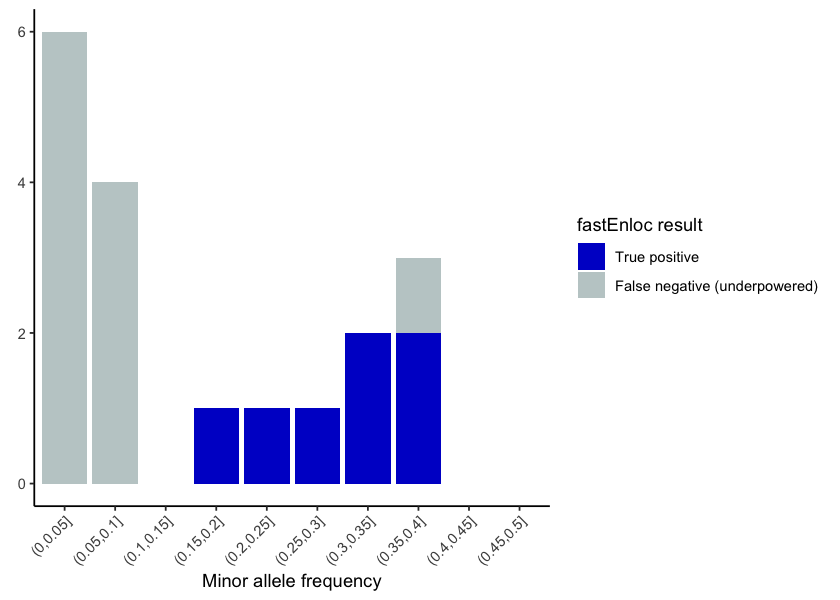

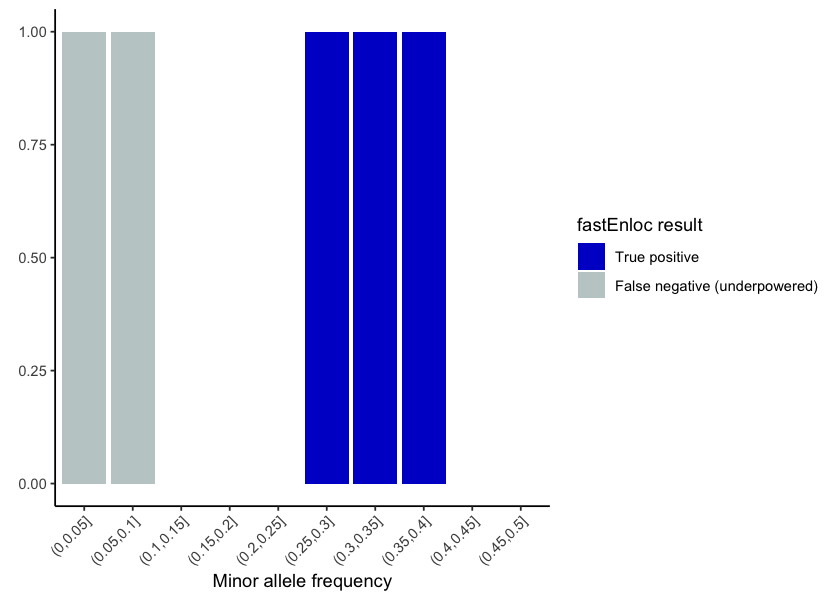

In [104]:
ctraits %>% 
    mutate(
        # species = factor(species, levels=c('human', 'cattle')),
        outcome = factor(outcome, levels = c('underpowered', 'incorrect', 'correct'))) %>%
    filter(!is.na(maf_bin), gwas %in% selected_loci$traits) %>%
ggplot(aes(x = maf_bin, fill=outcome)) + geom_bar() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
    # facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y') + 
    xlab('Minor allele frequency') + labs(fill = 'fastEnloc result') + ylab(element_blank()) + 
    scale_fill_manual(
        breaks=c('correct', 'incorrect', 'underpowered'), 
        values=c('blue3', 'lightpink3', 'azure3'),
        labels=c('True positive', 'False positive', 'False negative (underpowered)')
    ) + scale_x_discrete(drop=F)

ctraits %>% filter(!is.na(maf_bin), gwas %in% selected_loci$traits) %>% summarize(power = sum(outcome == 'correct') / sum(gwas %in% selected_loci$traits))
filt = filter_by_gwas_power(ctraits, 1e5, 35, 5e-8, 19930224, apply_filt=T)
filt %>% group_by(species) %>% filter(!is.na(maf_bin), gwas %in% selected_loci$traits) %>%summarize(power = sum(outcome == 'correct')/sum(gwas %in% selected_loci$traits))

filt %>% 
    mutate(
        # species = factor(species, levels=c('human', 'cattle')),
        outcome = factor(outcome, levels = c('underpowered', 'incorrect', 'correct'))) %>%
        filter(!is.na(maf_bin), gwas %in% selected_loci$traits) %>%
ggplot(aes(x = maf_bin, fill=outcome)) + geom_bar() + theme_classic() + theme(axis.text.x = element_text(angle = 45, vjust=1, hjust=1)) + 
    # facet_wrap(~forcats::fct_rev(case_when(species=='human'~'Human (CEU) demography', species=='cattle'~'Cattle-like demography')), scale='free_y') + 
    xlab('Minor allele frequency') + labs(fill = 'fastEnloc result') + ylab(element_blank()) + 
    scale_fill_manual(
        breaks=c('correct', 'incorrect', 'underpowered'), 
        values=c('blue3', 'lightpink3', 'azure3'),
        labels=c('True positive', 'False positive', 'False negative (underpowered)')
    ) + scale_x_discrete(drop=F)